In [24]:
with open("historical_projections.csv", "r") as f:
    csv_text = f.read()
    

print(csv_text)

Player,Position,ID,Draft Year,Projected SPM,Superstar,Starter,Role Player,Bust
Karl-Anthony Towns,C,karl-anthony-towns,2015,1.030605703,0.134766667,0.427183333,0.163083333,0.274966667
Justise Winslow,SF,justise-winslow,2015,0.875328997,0.083528571,0.510904762,0.176766667,0.2288
Stanley Johnson,SF,stanley-johnson,2015,0.679493305,0.0678,0.423733333,0.2785,0.229966667
Jahlil Okafor,C,jahlil-okafor,2015,0.521661276,0.058716667,0.4099,0.235533333,0.29585
D`Angelo Russell,PG,d-angelo-russell,2015,0.511966664,0.152033333,0.342283333,0.096583333,0.4091
Dakari Johnson,C,dakari-johnson,2015,0.491787354,0.021340778,0.36754357,0.417571997,0.193543655
Devin Booker,SG,3-devin-booker,2015,0.472577305,0.073366667,0.324466667,0.390166667,0.212
Willie Cauley-Stein,C,willie-cauley-stein,2015,0.351171383,0.047114455,0.405989863,0.243185719,0.303709963
Rondae Hollis-Jefferson,SF,rondae-hollis-jefferson,2015,0.311909198,0.014589784,0.368533143,0.392480667,0.224396406
Trey Lyles,PF,trey-lyles,2015,0.2675094

In [25]:
lines = csv_text.split("\n")

clean_lines = []       
current = ""           

for line in lines:
    line = line.strip()
    if line == "":
        continue
    
    
    current += line


    fields = current.split(",")

    
    if len(fields) == 9:
        clean_lines.append(current)
        current = ""   
    else:
        current += " "  


data = [row.split(",") for row in clean_lines]

data[:5]

[['Player',
  'Position',
  'ID',
  'Draft Year',
  'Projected SPM',
  'Superstar',
  'Starter',
  'Role Player',
  'Bust'],
 ['Karl-Anthony Towns',
  'C',
  'karl-anthony-towns',
  '2015',
  '1.030605703',
  '0.134766667',
  '0.427183333',
  '0.163083333',
  '0.274966667'],
 ['Justise Winslow',
  'SF',
  'justise-winslow',
  '2015',
  '0.875328997',
  '0.083528571',
  '0.510904762',
  '0.176766667',
  '0.2288'],
 ['Stanley Johnson',
  'SF',
  'stanley-johnson',
  '2015',
  '0.679493305',
  '0.0678',
  '0.423733333',
  '0.2785',
  '0.229966667'],
 ['Jahlil Okafor',
  'C',
  'jahlil-okafor',
  '2015',
  '0.521661276',
  '0.058716667',
  '0.4099',
  '0.235533333',
  '0.29585']]

In [26]:
header = data[0]

player_idx = header.index("Player")
pos_idx = header.index("Position")
superstar_idx = header.index("Superstar")

print("Players with Superstar probability > 0.10:\n")

for row in data[1:]:  # skip header
    superstar_prob = float(row[superstar_idx])
    
    if superstar_prob > 0.10:
        print(row[player_idx], "-", row[pos_idx], "→", superstar_prob) #prints players with a higher superstar probability

Players with Superstar probability > 0.10:

Karl-Anthony Towns - C → 0.134766667
D`Angelo Russell - PG → 0.152033333


In [27]:
header = data[0]
rows = data[1:]

draft_year_idx = header.index("Draft Year")

players_2015 = [row for row in rows if row[draft_year_idx] == "2015"]

len(players_2015)

73

In [28]:
header = data[0]
rows = data[1:]

draft_year_idx = header.index("Draft Year")
spm_idx = header.index("Projected SPM")

# Filter only 2015 draft players
players_2015 = [row for row in rows if row[draft_year_idx] == "2015"]

# Convert Projected SPM to float for correct sorting
for row in players_2015:
    row[spm_idx] = float(row[spm_idx])

# Sort by Projected SPM (highest first)
top_10_players = sorted(
    players_2015,
    key=lambda r: r[spm_idx],
    reverse=True
)[:10]

In [29]:
draft_year_idx = header.index("Draft Year")

players_2015 = [row for row in rows if row[draft_year_idx] == "2015"]

print("Number of 2015 players:", len(players_2015))

Number of 2015 players: 73


In [30]:
spm_idx = header.index("Projected SPM")

top_10_players = sorted(
    players_2015,
    key=lambda r: float(r[spm_idx]),
    reverse=True
)[:10]

print("Top 10 list length:", len(top_10_players))

Top 10 list length: 10


In [31]:
print("\nTop 10 Players from the 2015 Draft (by Projected SPM):\n")

for i, player in enumerate(top_10_players, start=1):
    print(f"Rank {i}")
    for col, val in zip(header, player):
        print(f"  {col}: {val}")
    print("-" * 40)


Top 10 Players from the 2015 Draft (by Projected SPM):

Rank 1
  Player: Karl-Anthony Towns
  Position: C
  ID: karl-anthony-towns
  Draft Year: 2015
  Projected SPM: 1.030605703
  Superstar: 0.134766667
  Starter: 0.427183333
  Role Player: 0.163083333
  Bust: 0.274966667
----------------------------------------
Rank 2
  Player: Justise Winslow
  Position: SF
  ID: justise-winslow
  Draft Year: 2015
  Projected SPM: 0.875328997
  Superstar: 0.083528571
  Starter: 0.510904762
  Role Player: 0.176766667
  Bust: 0.2288
----------------------------------------
Rank 3
  Player: Stanley Johnson
  Position: SF
  ID: stanley-johnson
  Draft Year: 2015
  Projected SPM: 0.679493305
  Superstar: 0.0678
  Starter: 0.423733333
  Role Player: 0.2785
  Bust: 0.229966667
----------------------------------------
Rank 4
  Player: Jahlil Okafor
  Position: C
  ID: jahlil-okafor
  Draft Year: 2015
  Projected SPM: 0.521661276
  Superstar: 0.058716667
  Starter: 0.4099
  Role Player: 0.235533333
  Bust: 

In [32]:
players_2015 = []

draft_year_idx = header.index("Draft Year")
spm_idx = header.index("Projected SPM")
superstar_idx = header.index("Superstar")
bust_idx = header.index("Bust")
player_idx = header.index("Player")

for row in rows:
    if row[draft_year_idx] == "2015":
        players_2015.append({
            "Player": row[player_idx],
            "SPM": float(row[spm_idx]),
            "Superstar": float(row[superstar_idx]),
            "Bust": float(row[bust_idx])
        })

len(players_2015)

73

In [33]:
import os

os.makedirs("images", exist_ok=True)

In [34]:
import matplotlib.pyplot as plt
plt.close("all")

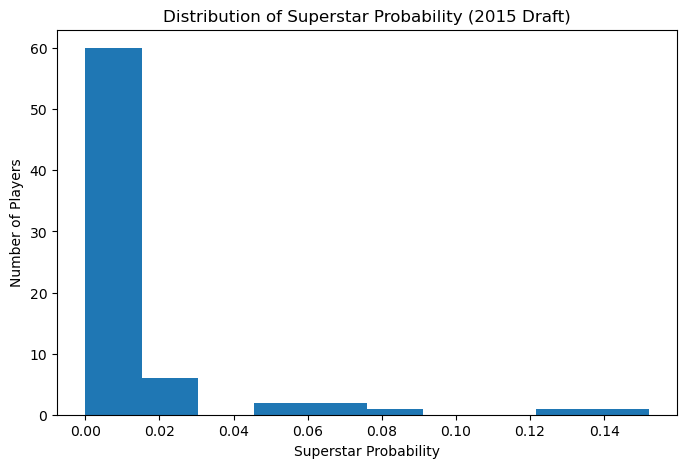

In [36]:
plt.figure(figsize=(8, 5))
plt.hist([p["Superstar"] for p in players_2015], bins=10)
plt.title("Distribution of Superstar Probability (2015 Draft)")
plt.xlabel("Superstar Probability")
plt.ylabel("Number of Players")

plt.savefig("images/superstar_distribution.png", bbox_inches="tight")
plt.show()
plt.close()

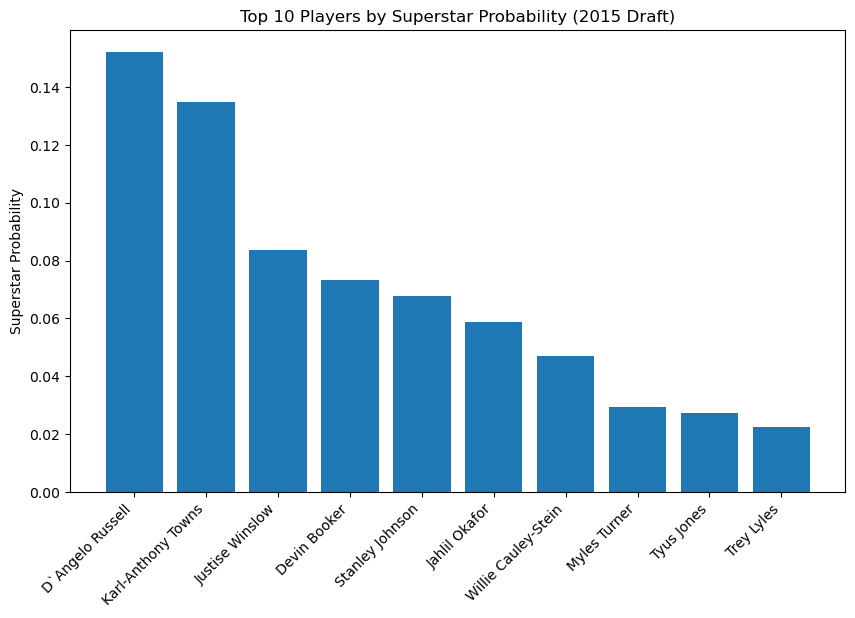

In [37]:
top_10 = sorted(players_2015, key=lambda p: p["Superstar"], reverse=True)[:10]

plt.figure(figsize=(10, 6))
plt.bar(
    [p["Player"] for p in top_10],
    [p["Superstar"] for p in top_10]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Superstar Probability")
plt.title("Top 10 Players by Superstar Probability (2015 Draft)")

plt.savefig("images/top_10_superstars.png", bbox_inches="tight")
plt.show()
plt.close()

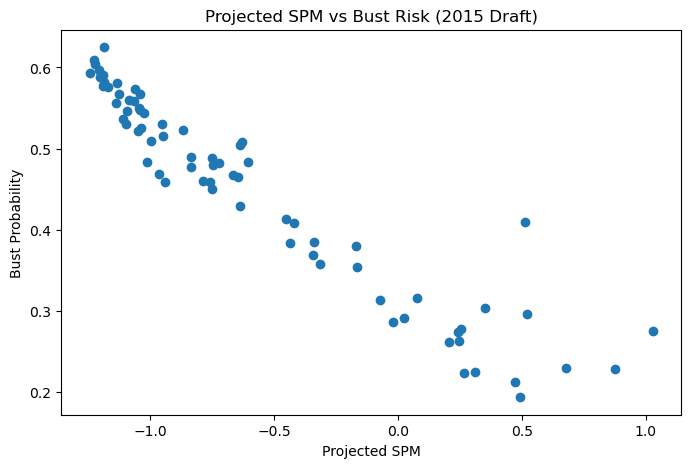

In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(
    [p["SPM"] for p in players_2015],
    [p["Bust"] for p in players_2015]
)
plt.xlabel("Projected SPM")
plt.ylabel("Bust Probability")
plt.title("Projected SPM vs Bust Risk (2015 Draft)")

plt.savefig("images/spm_vs_bust.png", bbox_inches="tight")
plt.show()
plt.close()